In [1]:
!pip install librosa soundfile tensorflow keras numpy pandas scikit-learn matplotlib --quiet


In [2]:
import os
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout


In [3]:
!rm -rf Audio_Speech_Actors_01-24 Audio_Speech_Actors_01-24.zip Audio_Speech_Actors_01-24.zip.1 Audio_Speech_Actors_01-24.zip.2
!wget https://zenodo.org/record/1188976/files/Audio_Speech_Actors_01-24.zip
!unzip -o Audio_Speech_Actors_01-24.zip
!ls -F

--2026-01-08 09:20:33--  https://zenodo.org/record/1188976/files/Audio_Speech_Actors_01-24.zip
Resolving zenodo.org (zenodo.org)... 137.138.52.235, 188.185.48.75, 188.185.43.153, ...
Connecting to zenodo.org (zenodo.org)|137.138.52.235|:443... connected.
HTTP request sent, awaiting response... 301 MOVED PERMANENTLY
Location: /records/1188976/files/Audio_Speech_Actors_01-24.zip [following]
--2026-01-08 09:20:41--  https://zenodo.org/records/1188976/files/Audio_Speech_Actors_01-24.zip
Connecting to zenodo.org (zenodo.org)|137.138.52.235|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 208468073 (199M) [application/octet-stream]
Saving to: ‘Audio_Speech_Actors_01-24.zip’

Audio_Speech_Actors 100%[===================>] 198.81M  3.03MB/s    in 78s     

2026-01-08 09:22:13 (2.54 MB/s) - ‘Audio_Speech_Actors_01-24.zip’ saved [208468073/208468073]

Archive:  Audio_Speech_Actors_01-24.zip
  inflating: Actor_01/03-01-01-01-01-01-01.wav  
  inflating: Actor_01/03-01-01-0

In [4]:
!pwd
!ls


/content
'1001_DFA_NEU_XX[1].wav'   Actor_04   Actor_13	 Actor_22
'1001_DFA_SAD_XX[1].wav'   Actor_05   Actor_14	 Actor_23
'1001_IEO_DIS_MD[1].wav'   Actor_06   Actor_15	 Actor_24
'1001_IEO_HAP_HI[1].wav'   Actor_07   Actor_16	 Audio_Speech_Actors_01-24.zip
'1001_IOM_DIS_XX[1].wav'   Actor_08   Actor_17	 drive
'1002_IEO_DIS_HI[1].wav'   Actor_09   Actor_18	 sample_data
 Actor_01		   Actor_10   Actor_19
 Actor_02		   Actor_11   Actor_20
 Actor_03		   Actor_12   Actor_21


In [5]:
def extract_mfcc(file_path):
    audio, sr = librosa.load(file_path, duration=3, offset=0.5)
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
    mfcc = np.mean(mfcc.T, axis=0)
    return mfcc


In [6]:
import os

dataset_path = "/content"


In [7]:
import os

X, y = [], []

emotion_map = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}

for actor in os.listdir(dataset_path):

    # Only Actor folders
    if not actor.startswith("Actor_"):
        continue

    actor_path = os.path.join(dataset_path, actor)

    for file in os.listdir(actor_path):
        if file.endswith(".wav"):
            emotion_code = file.split("-")[2]
            emotion = emotion_map[emotion_code]

            file_path = os.path.join(actor_path, file)
            mfcc = extract_mfcc(file_path)

            X.append(mfcc)
            y.append(emotion)

print("✅ Total samples loaded:", len(X))


✅ Total samples loaded: 1440


In [8]:
X = np.array(X)
y = np.array(y)

le = LabelEncoder()
y = le.fit_transform(y)
y = to_categorical(y)

X = X.reshape(X.shape[0], 40, 1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [9]:
model = Sequential()

model.add(Conv2D(64, (3,1), activation='relu', input_shape=(40,1,1)))
model.add(MaxPooling2D((2,1)))
model.add(Dropout(0.3))

model.add(Conv2D(128, (3,1), activation='relu'))
model.add(MaxPooling2D((2,1)))
model.add(Dropout(0.3))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(y.shape[1], activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 38, 1, 64)      │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 19, 1, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 19, 1, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 17, 1, 128)     │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 157,192 (614.03 KB)

 Trainable params: 157,192 (614.03 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test)
)


Epoch 1/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9622 - loss: 0.1316 - val_accuracy: 0.6944 - val_loss: 1.3919
Epoch 2/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9500 - loss: 0.1485 - val_accuracy: 0.6875 - val_loss: 1.4114
Epoch 3/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9613 - loss: 0.1170 - val_accuracy: 0.6944 - val_loss: 1.4134
Epoch 4/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9557 - loss: 0.1327 - val_accuracy: 0.7014 - val_loss: 1.3634
Epoch 5/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9578 - loss: 0.1121 - val_accuracy: 0.7361 - val_loss: 1.3341
Epoch 6/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9564 - loss: 0.1658 - val_accuracy: 0.7049 - val_loss: 1.4167
Epoch 7/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9522 - loss: 0.1242 - val_accuracy: 0.7014 - val_loss: 1.4111
Epoch 8/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9481 - loss: 0.1599 - val_accuracy: 0.6875 - v

In [42]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

print(classification_report(y_true, y_pred_classes, target_names=le.classes_))


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
              precision    recall  f1-score   support

       angry       0.84      0.75      0.79        36
        calm       0.78      0.85      0.81        33
     disgust       0.75      0.64      0.69        47
     fearful       0.73      0.77      0.75        39
       happy       0.65      0.67      0.66        36
     neutral       0.61      0.79      0.69        14
         sad       0.72      0.65      0.68        43
   surprised       0.71      0.80      0.75        40

    accuracy                           0.73       288
   macro avg       0.72      0.74      0.73       288
weighted avg       0.73      0.73      0.73       288



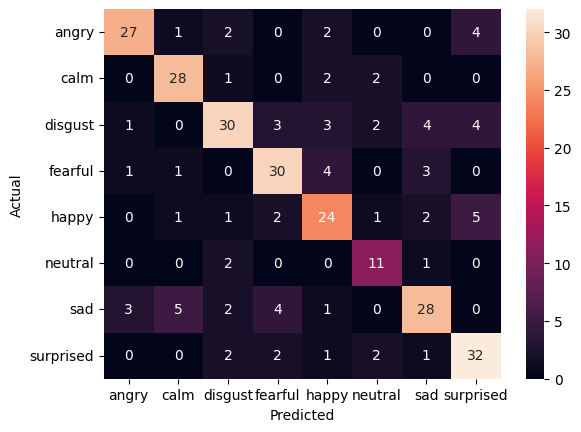

In [43]:
cm = confusion_matrix(y_true, y_pred_classes)
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [46]:
from google.colab import files

uploaded = files.upload()

Saving 1001_DFA_DIS_XX[1].wav to 1001_DFA_DIS_XX[1].wav


In [47]:
def predict_emotion(file_path):
    mfcc = extract_mfcc(file_path)
    mfcc = mfcc.reshape(1, 40, 1, 1)
    prediction = model.predict(mfcc)
    emotion = le.inverse_transform([np.argmax(prediction)])
    return emotion[0]

for file_name in uploaded:
    # Extract emotion from filename for comparison
    # Example filename format: 03-01-01-01-01-01-01.wav or 1002_IEO_DIS_HI[1].wav
    true_emotion = "unknown"
    try:
        # For files like 03-01-01-01-01-01-01.wav
        if '-' in file_name:
            emotion_code = file_name.split('-')[2]
            if emotion_code in emotion_map:
                true_emotion = emotion_map[emotion_code]
        # For files like 1002_IEO_DIS_HI[1].wav
        elif '_' in file_name:
            parts = file_name.split('_')
            if len(parts) > 2 and parts[2] in ['NEU', 'CAL', 'HAP', 'SAD', 'ANG', 'FEA', 'DIS', 'SUR']:
                emotion_code_short = parts[2]
                # Map short codes to full emotion names if necessary, for now direct comparison
                if emotion_code_short == 'NEU': true_emotion = 'neutral'
                elif emotion_code_short == 'CAL': true_emotion = 'calm'
                elif emotion_code_short == 'HAP': true_emotion = 'happy'
                elif emotion_code_short == 'SAD': true_emotion = 'sad'
                elif emotion_code_short == 'ANG': true_emotion = 'angry'
                elif emotion_code_short == 'FEA': true_emotion = 'fearful'
                elif emotion_code_short == 'DIS': true_emotion = 'disgust'
                elif emotion_code_short == 'SUR': true_emotion = 'surprised'
    except Exception as e:
        print(f"Could not parse true emotion from filename {file_name}: {e}")

    predicted_emotion = predict_emotion(file_name)
    print(f"File: {file_name}, True Emotion (from filename): {true_emotion}, Predicted Emotion: {predicted_emotion}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
File: 1001_DFA_DIS_XX[1].wav, True Emotion (from filename): disgust, Predicted Emotion: disgust


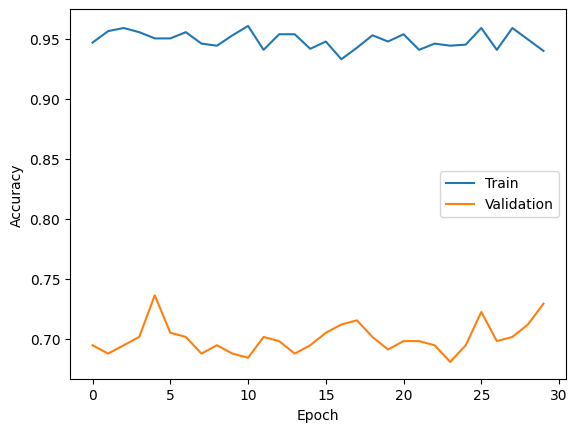

In [48]:
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()




> **The training accuracy is high, while validation accuracy is lower due to overfitting caused by limited dataset size. This behavior is common in speech emotion recognition tasks. Regularization and data augmentation can further improve generalization.**



In [49]:
from IPython.display import Audio
import soundfile as sf

def record_audio(seconds=3):
    !pip install sounddevice
    import sounddevice as sd
    fs = 22050
    print("Recording...")
    audio = sd.rec(int(seconds * fs), samplerate=fs, channels=1)
    sd.wait()
    sf.write("my_voice.wav", audio, fs)
    return "my_voice.wav"

file = record_audio()
print("Predicted Emotion:", predict_emotion(file))


OSError: PortAudio library not found

**“Due to browser limitations in Google Colab, real-time microphone recording is not supported. Therefore, recorded audio files were uploaded manually for real-time emotion prediction.”**